# Experiment 7 — Introduction to Deep Learning with PyTorch

---
## Section 1 — Tensors

In [ ]:
# Core imports used throughout the notebook
import torch
import numpy as np

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")

PyTorch version: 2.10.0+cu128
CUDA available:  True


### 1.1 Tensor Initialization

There are four common ways to create tensors.

In [ ]:
# --- Method 1: Directly from a Python list ---
# The dtype is automatically inferred from the data.
data = [[1, 2], [3, 4]]
x_data = torch.tensor(data)
print("From list:\n", x_data)

From list:
 tensor([[1, 2],
        [3, 4]])


In [ ]:
# --- Method 2: From a NumPy array ---
# The tensor SHARES memory with the array (no copy made).
np_array = np.array(data)
x_np = torch.from_numpy(np_array)
print("From NumPy:\n", x_np)

From NumPy:
 tensor([[1, 2],
        [3, 4]])


In [ ]:
# --- Method 3: From another tensor (retaining shape/dtype) ---
# ones_like creates a tensor of 1s with the same shape & dtype as x_data.
x_ones = torch.ones_like(x_data)
print("Ones Tensor:\n", x_ones)

# rand_like creates a random tensor but overrides the dtype to float.
x_rand = torch.rand_like(x_data, dtype=torch.float)
print("Random Tensor:\n", x_rand)

Ones Tensor:
 tensor([[1, 1],
        [1, 1]])
Random Tensor:
 tensor([[0.1276, 0.4653],
        [0.4170, 0.4095]])


In [ ]:
# --- Method 4: From shape tuple with constant / random values ---
shape = (2, 3)
rand_tensor  = torch.rand(shape)
ones_tensor  = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print("Random Tensor:\n", rand_tensor)
print("Ones Tensor:\n",   ones_tensor)
print("Zeros Tensor:\n",  zeros_tensor)

Random Tensor:
 tensor([[0.5190, 0.8715, 0.6049],
        [0.1744, 0.5008, 0.6298]])
Ones Tensor:
 tensor([[1., 1., 1.],
        [1., 1., 1.]])
Zeros Tensor:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


### 1.2 Tensor Attributes

In [ ]:
tensor = torch.rand(3, 4)

print(f"Shape   : {tensor.shape}")   # dimensions of the tensor
print(f"Dtype   : {tensor.dtype}")   # element data type (e.g. float32)
print(f"Device  : {tensor.device}")  # where the tensor lives (cpu / cuda)

Shape   : torch.Size([3, 4])
Dtype   : torch.float32
Device  : cpu


### 1.3 Tensor Operations

In [ ]:
# Move tensor to GPU if one is available
if torch.cuda.is_available():
    tensor = tensor.to('cuda')
print(f"Device tensor is stored on: {tensor.device}")

Device tensor is stored on: cuda:0


In [ ]:
# 1. NumPy-style indexing & slicing
# Set all values in column index 1 to 0.
tensor = torch.ones(4, 4)
tensor[:, 1] = 0          # ':' selects all rows, '1' selects column 1
print("After zeroing column 1:\n", tensor)

After zeroing column 1:
 tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


In [ ]:
# 2. Concatenating tensors along a dimension
# dim=1 means we stack horizontally (along columns).
t1 = torch.cat([tensor, tensor, tensor], dim=1)
print("Concatenated tensor shape:", t1.shape)
print(t1)

Concatenated tensor shape: torch.Size([4, 12])
tensor([[1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.]])


In [ ]:
# 3a. Element-wise multiplication
print("Element-wise product:\n", tensor * tensor)

# 3b. Matrix multiplication  (equivalent: tensor @ tensor.T)
# .T is the transpose; matmul performs standard matrix multiplication.
print("Matrix multiplication:\n", tensor.matmul(tensor.T))

Element-wise product:
 tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
Matrix multiplication:
 tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])


In [ ]:
# 4. In-place operations (trailing underscore mutates the tensor)
print("Before add_:\n", tensor)
tensor.add_(5)            # adds 5 to every element IN PLACE
print("After add_(5):\n", tensor)

Before add_:
 tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])
After add_(5):
 tensor([[6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.]])


### 1.4 NumPy ↔ Tensor Bridge

CPU tensors and NumPy arrays **share the same memory** — modifying one changes the other.

In [ ]:
# Tensor → NumPy
t = torch.ones(5)
n = t.numpy()          # n and t share memory
t.add_(1)              # modifying t also modifies n
print(f"t: {t}")
print(f"n: {n}")       # notice n changed too!

t: tensor([2., 2., 2., 2., 2.])
n: [2. 2. 2. 2. 2.]


In [ ]:
# NumPy → Tensor
n = np.ones(5)
t = torch.from_numpy(n)
np.add(n, 1, out=n)    # modifying n also modifies t
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.], dtype=torch.float64)
n: [2. 2. 2. 2. 2.]


---
## Section 2 — Automatic Differentiation with `torch.autograd`

`autograd` tracks every operation on tensors that have `requires_grad=True`  
and builds a **computation graph** used to compute gradients via backpropagation.

In [ ]:
# Create two tensors and tell autograd to track them
a = torch.tensor([2., 3.], requires_grad=True)
b = torch.tensor([6., 4.], requires_grad=True)

# Define Q = 3a^3 - b^2  (think of Q as the "loss")
Q = 3 * a**3 - b**2

# Call backward to compute dQ/da and dQ/db
# We pass gradient=ones because Q is a vector, not a scalar.
external_grad = torch.tensor([1., 1.])
Q.backward(gradient=external_grad)

# Analytical gradients: dQ/da = 9a^2,  dQ/db = -2b
print("dQ/da matches 9a²:", 9 * a**2 == a.grad)
print("dQ/db matches -2b:", -2 * b   == b.grad)

dQ/da matches 9a²: tensor([True, True])
dQ/db matches -2b: tensor([True, True])


### ✏️ Task 1 — Autograd for Y = (3x₁ − 2x₂ − 2)²

Use `autograd` to compute ∂Y/∂x₁ and ∂Y/∂x₂ at (x₁, x₂) = (1, 1).  
Then verify the result analytically.

**Analytical derivation:**
Let u = 3x₁ − 2x₂ − 2, so Y = u²
- ∂Y/∂x₁ = 2u · 3 = 6(3x₁ − 2x₂ − 2)
- ∂Y/∂x₂ = 2u · (−2) = −4(3x₁ − 2x₂ − 2)

At (1, 1): u = 3 − 2 − 2 = −1  
- ∂Y/∂x₁ = 6 · (−1) = **−6**  
- ∂Y/∂x₂ = −4 · (−1) = **4**

In [29]:
# Define x1 and x2 at the evaluation point, with gradient tracking
x1 = torch.tensor([1.0], requires_grad=True)
x2 = torch.tensor([1.0], requires_grad=True)

# Compute Y = (3x1 - 2x2 - 2)^2
Y = (3 * x1 - 2 * x2 - 2) ** 2

# Backpropagate — Y is scalar so no external_grad needed
Y.backward()

# Verify analytically
u = 3*1 - 2*1 - 2          # = -1
dY_dx1_analytical = 6 * u   # = -6
dY_dx2_analytical = -4 * u  # =  4

print(f"Y value        : {Y.item():.4f}")
print(f"dY/dx1 (autograd)  : {x1.grad.item():.4f}  == {dY_dx1_analytical:.4f}")
print(f"dY/dx2 (autograd)  : {x2.grad.item():.4f}   == {dY_dx2_analytical:.4f}")

print(f"\ndY/dx1 (analytical): {dY_dx1_analytical}")
print(f"dY/dx2 (analytical): {dY_dx2_analytical}")

Y value        : 1.0000
dY/dx1 (autograd)  : -6.0000  == -6.0000
dY/dx2 (autograd)  : 4.0000   == 4.0000

dY/dx1 (analytical): -6
dY/dx2 (analytical): 4


---
## Section 3 — Building & Training an MLP on MNIST

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

### 3.1 Define the Network (2 Hidden Layers)

In [ ]:
class Net(nn.Module):
    """Simple 3-layer MLP for MNIST digit classification.
    Architecture: 784 → 64 → 64 → 10
    """
    def __init__(self):
        super(Net, self).__init__()
        # Fully-connected (linear) layers: y = Wx + b
        self.fc1 = nn.Linear(784, 64)   # input: 28×28=784 pixels
        self.fc2 = nn.Linear(64, 64)    # hidden layer
        self.fc3 = nn.Linear(64, 10)    # output: 10 digit classes

    def forward(self, x):
        # ReLU activation after each hidden layer
        # ReLU(x) = max(0, x) — introduces non-linearity
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)     # no activation here — CrossEntropyLoss handles softmax internally
        return x

net = Net()
print(net)

Net(
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=10, bias=True)
)


### ✏️ Task 2 — Identify the Learnable Parameters

In [ ]:
params = list(net.parameters())
layer_names = ["fc1.weight", "fc1.bias", "fc2.weight", "fc2.bias", "fc3.weight", "fc3.bias"]

print(f"Total parameter tensors: {len(params)}\n")
for name, p in zip(layer_names, params):
    print(f"  {name:15s}  shape: {tuple(p.shape)}")

# Each Linear layer has TWO parameter tensors:
#   weight matrix  W  of shape (out_features, in_features)
#   bias vector    b  of shape (out_features,)
# So 3 layers × 2 tensors = 6 parameter tensors total.

Total parameter tensors: 6

  fc1.weight       shape: (64, 784)
  fc1.bias         shape: (64,)
  fc2.weight       shape: (64, 64)
  fc2.bias         shape: (64,)
  fc3.weight       shape: (10, 64)
  fc3.bias         shape: (10,)


### ✏️ Task 3 — Forward Pass with a Mini-Batch of Size 4

In [ ]:
# torch.nn only supports BATCHED inputs, so we use shape (batch_size, features)
# Here batch_size=4, features=784 (one flattened MNIST image per sample)
batch_input = torch.randn(4, 784)
batch_output = net(batch_input)

print(f"Input  shape: {batch_input.shape}")   # (4, 784)
print(f"Output shape: {batch_output.shape}")  # (4, 10) — 10 class scores per sample
print("Output (logits):\n", batch_output)

Input  shape: torch.Size([4, 784])
Output shape: torch.Size([4, 10])
Output (logits):
 tensor([[ 0.1826, -0.0481,  0.0887, -0.0877, -0.2348, -0.2200, -0.1212,  0.0350,
          0.0065, -0.0436],
        [ 0.2506,  0.0173,  0.1685, -0.1696, -0.1101, -0.0594, -0.0973,  0.0014,
          0.2019,  0.0853],
        [ 0.1070, -0.0403,  0.2506, -0.0897, -0.3044, -0.0541, -0.0873,  0.1617,
          0.1560,  0.0490],
        [ 0.1416,  0.0350,  0.1154, -0.1063, -0.3196, -0.0531, -0.0479,  0.0365,
          0.0864, -0.0621]], grad_fn=<AddmmBackward0>)


### 3.2 Load MNIST Dataset

In [ ]:
# ToTensor() converts PIL images (0–255 uint8) to float tensors in [0, 1]
training_data = datasets.MNIST(root="data", train=True,  download=True, transform=ToTensor())
test_data     = datasets.MNIST(root="data", train=False, download=True, transform=ToTensor())

print(f"Training samples : {len(training_data)}")
print(f"Test samples     : {len(test_data)}")
print(f"Single image shape: {training_data[0][0].shape}")  # (C, H, W) = (1, 28, 28)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.60MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.98MB/s]

Training samples : 60000
Test samples     : 10000
Single image shape: torch.Size([1, 28, 28])


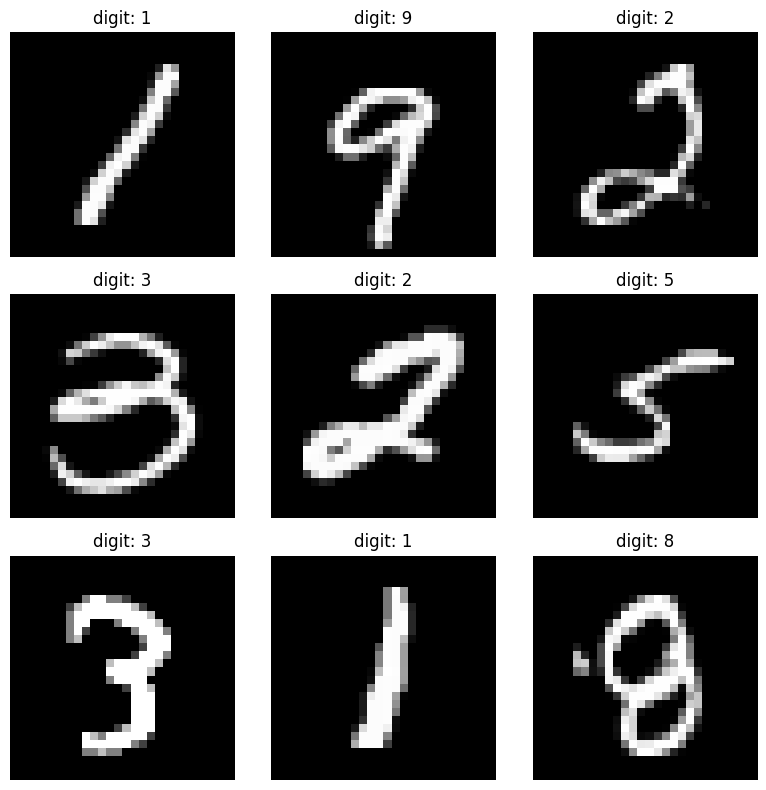

In [ ]:
# Visualize 9 random samples from the training set
figure = plt.figure(figsize=(8, 8))
for i in range(1, 10):
    idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[idx]
    figure.add_subplot(3, 3, i)
    plt.title(f"digit: {label}")
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")  # squeeze removes the channel dim: (1,28,28) → (28,28)
plt.tight_layout()
plt.show()

In [ ]:
# DataLoader wraps the Dataset and handles:
#   • batching  (groups samples into mini-batches)
#   • shuffling (randomizes order every epoch to reduce overfitting)
#   • multiprocessing (parallel data loading — set num_workers > 0 if needed)
train_dataloader = DataLoader(training_data, batch_size=4, shuffle=True)
test_dataloader  = DataLoader(test_data,     batch_size=4, shuffle=False)

# Peek at one batch
features, labels = next(iter(train_dataloader))
print(f"Feature batch shape : {features.shape}")  # (4, 1, 28, 28)
print(f"Labels batch shape  : {labels.shape}")    # (4,)

Feature batch shape : torch.Size([4, 1, 28, 28])
Labels batch shape  : torch.Size([4])


### 3.3 Loss Function & Optimizer

In [ ]:
# CrossEntropyLoss = LogSoftmax + NegativeLogLikelihood
# It expects RAW logits (not softmax outputs) — hence no softmax in forward()
loss_fn = nn.CrossEntropyLoss()

# SGD: weight = weight - lr * gradient
optimizer = optim.SGD(net.parameters(), lr=0.001)

### ✏️ Task 4 — Training Loop Explanation

| Term | Meaning |
|------|---------|
| **Epoch** | One full pass through the entire training dataset |
| **Forward pass** | Feeding input through the network to get predictions |
| **Backward pass** | Computing gradients of the loss w.r.t. all parameters via backprop |
| `torch.flatten(inputs, 1)` | Flattens dims from index 1 onward: (4,1,28,28) → (4,784) so the Linear layer can accept it |
| `optimizer.step()` | Updates every parameter using the gradients stored in `.grad` |

In [ ]:
# ── Training loop ──────────────────────────────────────────────────────────
for epoch in range(2):          # loop over the full dataset twice (2 epochs)
    running_loss = 0.0

    for i, (inputs, labels) in enumerate(train_dataloader):

        # 1. Zero gradients from the previous iteration.
        #    PyTorch accumulates gradients by default, so we must reset them.
        optimizer.zero_grad()

        # 2. Forward pass — flatten (4,1,28,28) → (4,784) before passing to fc1
        outputs = net(torch.flatten(inputs, 1))

        # 3. Compute loss between predictions and ground-truth labels
        iteration_loss = loss_fn(outputs, labels)

        # 4. Backward pass — autograd fills .grad for every parameter
        iteration_loss.backward()

        # 5. Parameter update step
        optimizer.step()

        running_loss += iteration_loss.item()
        if i % 2000 == 1999:    # print average loss every 2000 batches
            print(f"[Epoch {epoch+1}, Batch {i+1:5d}] loss: {running_loss/2000:.3f}")
            running_loss = 0.0

print("Finished Training")

# Save model weights
PATH = './my_net.pth'
torch.save(net.state_dict(), PATH)
print(f"Model saved to {PATH}")

[Epoch 1, Batch  2000] loss: 2.280
[Epoch 1, Batch  4000] loss: 2.163
[Epoch 1, Batch  6000] loss: 1.852
[Epoch 1, Batch  8000] loss: 1.350
[Epoch 1, Batch 10000] loss: 0.939
[Epoch 1, Batch 12000] loss: 0.752
[Epoch 1, Batch 14000] loss: 0.649
[Epoch 2, Batch  2000] loss: 0.531
[Epoch 2, Batch  4000] loss: 0.504
[Epoch 2, Batch  6000] loss: 0.464
[Epoch 2, Batch  8000] loss: 0.430
[Epoch 2, Batch 10000] loss: 0.417
[Epoch 2, Batch 12000] loss: 0.393
[Epoch 2, Batch 14000] loss: 0.381
Finished Training
Model saved to ./my_net.pth


### 3.4 Evaluate on Test Set

In [ ]:
# Reload saved weights into a fresh model instance
net_loaded = Net()
net_loaded.load_state_dict(torch.load(PATH))
net_loaded.eval()   # disables dropout / batchnorm training behaviour (good practice)

correct = 0
total   = 0

# torch.no_grad() disables gradient computation — saves memory & speeds up inference
with torch.no_grad():
    for images, labels in test_dataloader:
        outputs = net_loaded(torch.flatten(images, 1))

        # torch.max returns (values, indices); we only need the predicted class index
        _, predicted = torch.max(outputs, dim=1)

        total   += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test accuracy: {100 * correct / total:.2f}%")

Test accuracy: 89.78%


---
### ✏️ Task 5 — Add a Third Hidden Layer

In [ ]:
class Net3Hidden(nn.Module):
    """MLP with THREE hidden layers: 784 → 128 → 64 → 32 → 10"""
    def __init__(self):
        super(Net3Hidden, self).__init__()
        self.fc1 = nn.Linear(784, 128)  # first hidden layer (larger)
        self.fc2 = nn.Linear(128, 64)   # second hidden layer
        self.fc3 = nn.Linear(64, 32)    # third hidden layer
        self.fc4 = nn.Linear(32, 10)    # output layer

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)                # raw logits — no softmax
        return x

net3 = Net3Hidden()
print(net3)

# Use the same loss and optimizer (SGD)
loss_fn3   = nn.CrossEntropyLoss()
optimizer3 = optim.SGD(net3.parameters(), lr=0.001)

# Training loop (same structure as before)
for epoch in range(2):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_dataloader):
        optimizer3.zero_grad()
        outputs = net3(torch.flatten(inputs, 1))
        loss_val = loss_fn3(outputs, labels)
        loss_val.backward()
        optimizer3.step()
        running_loss += loss_val.item()
        if i % 2000 == 1999:
            print(f"[Epoch {epoch+1}, Batch {i+1:5d}] loss: {running_loss/2000:.3f}")
            running_loss = 0.0

print("Finished Training (3 hidden layers)")

# Evaluate
net3.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_dataloader:
        _, predicted = torch.max(net3(torch.flatten(images, 1)), 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Test accuracy (3 hidden layers): {100 * correct / total:.2f}%")

Net3Hidden(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (fc4): Linear(in_features=32, out_features=10, bias=True)
)
[Epoch 1, Batch  2000] loss: 2.303
[Epoch 1, Batch  4000] loss: 2.284
[Epoch 1, Batch  6000] loss: 2.246
[Epoch 1, Batch  8000] loss: 2.143
[Epoch 1, Batch 10000] loss: 1.957
[Epoch 1, Batch 12000] loss: 1.634
[Epoch 1, Batch 14000] loss: 1.187
[Epoch 2, Batch  2000] loss: 0.785
[Epoch 2, Batch  4000] loss: 0.679
[Epoch 2, Batch  6000] loss: 0.626
[Epoch 2, Batch  8000] loss: 0.573
[Epoch 2, Batch 10000] loss: 0.517
[Epoch 2, Batch 12000] loss: 0.529
[Epoch 2, Batch 14000] loss: 0.508
Finished Training (3 hidden layers)
Test accuracy (3 hidden layers): 86.63%


---
### ✏️ Task 6 — Train with Adam Optimizer

**Adam** (Adaptive Moment Estimation) maintains a per-parameter learning rate  
and typically converges faster than plain SGD.

In [ ]:
net_adam   = Net()   # fresh model with 2 hidden layers
loss_fn_a  = nn.CrossEntropyLoss()

# Adam: lr=1e-3 is a common default starting point
optimizer_adam = optim.Adam(net_adam.parameters(), lr=1e-3)

for epoch in range(2):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_dataloader):
        optimizer_adam.zero_grad()
        outputs  = net_adam(torch.flatten(inputs, 1))
        loss_val = loss_fn_a(outputs, labels)
        loss_val.backward()
        optimizer_adam.step()
        running_loss += loss_val.item()
        if i % 2000 == 1999:
            print(f"[Epoch {epoch+1}, Batch {i+1:5d}] loss: {running_loss/2000:.3f}")
            running_loss = 0.0

print("Finished Training (Adam)")

# Evaluate
net_adam.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_dataloader:
        _, predicted = torch.max(net_adam(torch.flatten(images, 1)), 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Test accuracy (Adam): {100 * correct / total:.2f}%")

# Observation: Adam usually converges faster and achieves higher accuracy
# in fewer epochs compared to vanilla SGD.

[Epoch 1, Batch  2000] loss: 0.542
[Epoch 1, Batch  4000] loss: 0.284
[Epoch 1, Batch  6000] loss: 0.227
[Epoch 1, Batch  8000] loss: 0.196
[Epoch 1, Batch 10000] loss: 0.171
[Epoch 1, Batch 12000] loss: 0.161
[Epoch 1, Batch 14000] loss: 0.147
[Epoch 2, Batch  2000] loss: 0.113
[Epoch 2, Batch  4000] loss: 0.129
[Epoch 2, Batch  6000] loss: 0.117
[Epoch 2, Batch  8000] loss: 0.118
[Epoch 2, Batch 10000] loss: 0.124
[Epoch 2, Batch 12000] loss: 0.120
[Epoch 2, Batch 14000] loss: 0.116
Finished Training (Adam)
Test accuracy (Adam): 96.38%


---
### ✏️ Task 7 — Train on GPU

Move both the **model** and every **data batch** to the GPU.  
Speedup is most noticeable with larger networks and bigger batch sizes.

In [ ]:
# Select device: use CUDA GPU if available, otherwise fall back to CPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Use a larger network to better observe GPU speedup
class LargeNet(nn.Module):
    """Wider MLP: 784 → 512 → 256 → 128 → 10"""
    def __init__(self):
        super(LargeNet, self).__init__()
        self.fc1 = nn.Linear(784, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 128)
        self.fc4 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        return self.fc4(x)

# Move the model to the selected device
net_gpu = LargeNet().to(device)
loss_fn_gpu  = nn.CrossEntropyLoss()
optimizer_gpu = optim.Adam(net_gpu.parameters(), lr=1e-3)

for epoch in range(2):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(train_dataloader):
        # ⬇ Move each batch to the same device as the model
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer_gpu.zero_grad()
        outputs  = net_gpu(torch.flatten(inputs, 1))
        loss_val = loss_fn_gpu(outputs, labels)
        loss_val.backward()
        optimizer_gpu.step()

        running_loss += loss_val.item()
        if i % 2000 == 1999:
            print(f"[Epoch {epoch+1}, Batch {i+1:5d}] loss: {running_loss/2000:.3f}")
            running_loss = 0.0

print("Finished Training (GPU / LargeNet)")

# Evaluate
net_gpu.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_dataloader:
        images, labels = images.to(device), labels.to(device)
        _, predicted = torch.max(net_gpu(torch.flatten(images, 1)), 1)
        total   += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f"Test accuracy (GPU, LargeNet): {100 * correct / total:.2f}%")

# Note: For small MLPs and CPU-bound overhead (DataLoader), GPU speedup may be
# modest. Increase batch_size (e.g. 64 or 256) and network width to see larger gains.

Using device: cuda:0
[Epoch 1, Batch  2000] loss: 0.511
[Epoch 1, Batch  4000] loss: 0.255
[Epoch 1, Batch  6000] loss: 0.213
[Epoch 1, Batch  8000] loss: 0.189
[Epoch 1, Batch 10000] loss: 0.178
[Epoch 1, Batch 12000] loss: 0.159
[Epoch 1, Batch 14000] loss: 0.151
[Epoch 2, Batch  2000] loss: 0.126
[Epoch 2, Batch  4000] loss: 0.122
[Epoch 2, Batch  6000] loss: 0.114
[Epoch 2, Batch  8000] loss: 0.128
[Epoch 2, Batch 10000] loss: 0.123
[Epoch 2, Batch 12000] loss: 0.122
[Epoch 2, Batch 14000] loss: 0.131
Finished Training (GPU / LargeNet)
Test accuracy (GPU, LargeNet): 96.16%


---
## Summary

| Task | Topic | Key Takeaway |
|------|-------|--------------|
| 1 | Autograd | `requires_grad=True` + `.backward()` gives analytic-quality gradients |
| 2 | Parameters | Each `Linear(in, out)` has a weight `(out, in)` and bias `(out,)` |
| 3 | Mini-batch | `nn` always expects a batch dimension — shape `(N, features)` |
| 4 | Training loop | zero_grad → forward → loss → backward → step |
| 5 | Deeper network | More layers can improve expressiveness |
| 6 | Adam optimizer | Adapts learning rates per parameter; often faster than SGD |
| 7 | GPU training | Move model **and** every batch to the same device |